<a href="https://colab.research.google.com/github/SUHANI-21/MachineLearningLab-2/blob/main/K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# K-MEANS CLUSTERING USING BUILT-IN IRIS DATASET
# ============================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# ============================================================
# 2. LOAD BUILT-IN IRIS DATASET
# ============================================================

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("Iris Dataset:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)



Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Dataset Shape:
(150, 4)


In [2]:
# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 4. SUMMARY STATISTICS
# ============================================================

print("\nSummary Statistics:")
display(df.describe())


Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Summary Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [3]:
# ============================================================
# 5. SELECT FEATURES
# ============================================================

# We use all four numerical features
X = df[
    [
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)'
    ]
]

In [4]:
# NOTE:
# We do NOT use iris.target because K-Means is unsupervised.

# ============================================================
# 6. APPLY K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit model and assign clusters
df['Cluster'] = kmeans.fit_predict(X)

# ============================================================
# 7. DISPLAY CLUSTERED DATA
# ============================================================

print("\nClustered Dataset:")
display(df.head(10))


Clustered Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


In [5]:
# ============================================================
# 8. CLUSTER CENTERS
# ============================================================

print("\nCluster Centers:")

centers = kmeans.cluster_centers_

for i, center in enumerate(centers):
    print(f"\nCluster {i}:")
    print("Sepal Length :", center[0])
    print("Sepal Width  :", center[1])
    print("Petal Length :", center[2])
    print("Petal Width  :", center[3])


Cluster Centers:

Cluster 0:
Sepal Length : 5.901612903225806
Sepal Width  : 2.7483870967741937
Petal Length : 4.393548387096774
Petal Width  : 1.4338709677419355

Cluster 1:
Sepal Length : 5.006
Sepal Width  : 3.428
Petal Length : 1.4620000000000002
Petal Width  : 0.24600000000000055

Cluster 2:
Sepal Length : 6.85
Sepal Width  : 3.0736842105263156
Petal Length : 5.742105263157894
Petal Width  : 2.0710526315789473


In [6]:
# ============================================================
# 9. NUMBER OF POINTS IN EACH CLUSTER
# ============================================================

print("\nNumber of samples in each cluster:")
print(df['Cluster'].value_counts().sort_index())



Number of samples in each cluster:
Cluster
0    62
1    50
2    38
Name: count, dtype: int64


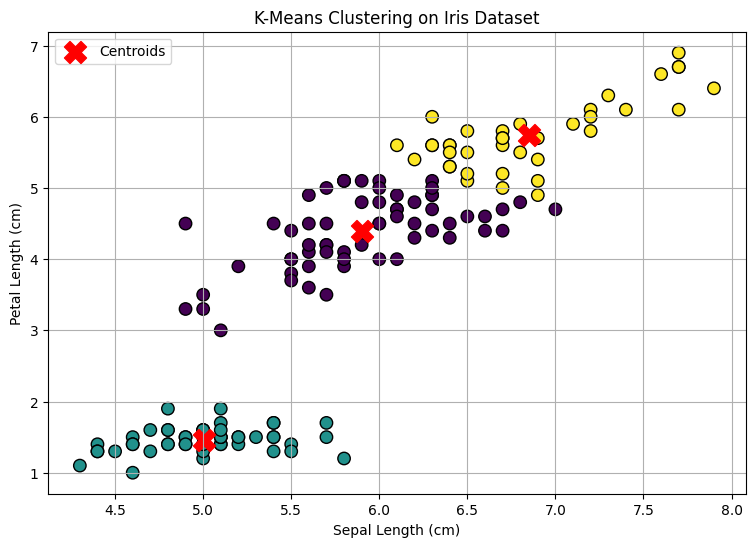

In [7]:
# ============================================================
# 10. VISUALIZE CLUSTERS
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    df['sepal length (cm)'],
    df['petal length (cm)'],
    c=df['Cluster'],
    cmap='viridis',
    s=80,
    edgecolor='black'
)

# Plot centroids using the corresponding two features
plt.scatter(
    centers[:, 0],
    centers[:, 2],
    c='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# ============================================================
# 11. FINAL CLUSTER INFORMATION
# ============================================================

print("\nFinal Clusters:")

for cluster in sorted(df['Cluster'].unique()):

    print(f"\nCluster {cluster}:")
    display(
        df[df['Cluster'] == cluster]
    )


Final Clusters:

Cluster 0:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0
55,5.7,2.8,4.5,1.3,0
...,...,...,...,...,...
133,6.3,2.8,5.1,1.5,0
138,6.0,3.0,4.8,1.8,0
142,5.8,2.7,5.1,1.9,0
146,6.3,2.5,5.0,1.9,0



Cluster 1:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1



Cluster 2:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
52,6.9,3.1,4.9,1.5,2
77,6.7,3.0,5.0,1.7,2
100,6.3,3.3,6.0,2.5,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2
105,7.6,3.0,6.6,2.1,2
107,7.3,2.9,6.3,1.8,2
108,6.7,2.5,5.8,1.8,2
109,7.2,3.6,6.1,2.5,2
